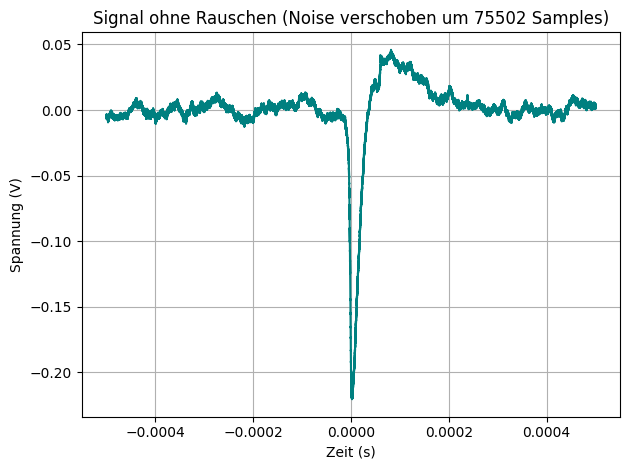

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Lade CSV-Dateien
file_signal = '/Users/rojinaksu/PycharmProjects/diy-particle-detector-V2/codes/Signal tests/Tek025.csv'
file_noise = '/Users/rojinaksu/PycharmProjects/diy-particle-detector-V2/codes/Signal tests/Tek026.csv'

df_signal = pd.read_csv(file_signal, header=None)
df_noise = pd.read_csv(file_noise, header=None)

# Spalten benennen
df_signal.columns = ['time', 'signal']
df_noise.columns = ['time', 'noise']

# Gemeinsame Zeitbasis verwenden
merged = pd.merge(df_signal, df_noise, on='time', how='inner')
x = merged['time'].to_numpy()
signal = merged['signal'].to_numpy()
noise = merged['noise'].to_numpy()

# Mittelwert entfernen für bessere Kreuzkorrelation
signal_demeaned = signal - np.mean(signal)
noise_demeaned = noise - np.mean(noise)

from scipy.signal import correlate, correlation_lags

# FFT-basierte Kreuzkorrelation
corr = correlate(signal_demeaned, noise_demeaned, mode='full', method='fft')
lags = correlation_lags(len(signal), len(noise), mode='full')
lag = lags[np.argmax(corr)]


# Noise verschieben (rollen)
noise_aligned = np.roll(noise, lag)

# Falls nötig: Noise am Rand mit 0 auffüllen, um Artefakte zu minimieren
if lag > 0:
    noise_aligned[:lag] = 0
elif lag < 0:
    noise_aligned[lag:] = 0

# Rauschbereinigtes Signal
y = signal - noise_aligned

# Plot
#plt.figure(figsize=(10, 4))
plt.plot(x, y, color='teal')
plt.xlabel('Zeit (s)')
plt.ylabel('Spannung (V)')
plt.grid(True)
plt.title(f'Signal ohne Rauschen (Noise verschoben um {lag} Samples)')
plt.tight_layout()
#plt.savefig('signalohneRauschen.pdf')
plt.show()





In [5]:
# Bereich definieren (z. B. vor Signalpeak = nur Rauschen, um Signalpeak = Signal)
# Werte hier sind Indizes – anpassen!
noise_window = y[:1000]
signal_window = y[1000:2000]

# Mittlere Leistung berechnen
P_signal = np.mean(signal_window**2)
P_noise = np.mean(noise_window**2)

# SNR in dB
snr_db = 10 * np.log10(P_signal / P_noise)
print(f"SNR = {snr_db:.2f} dB")


SNR = -0.15 dB


In [8]:
snr_raw = np.mean(df_signal['signal']**2) / np.mean(df_noise['noise']**2)
snr_db = 10 * np.log10(snr_raw)
std_signal = np.std(df_signal['signal'])
std_noise = np.std(df_noise['noise'])
print(f"Sigma Signal: {std_signal:.3e}, Sigma Noise: {std_noise:.3e}")

snr_est = (np.max(y) - np.min(y)) / (2 * np.std(df_noise['noise']))
print(f"Geschätztes SNR: {snr_est:.2f}")


Sigma Signal: 2.892e-02, Sigma Noise: 3.221e-03
Geschätztes SNR: 41.37


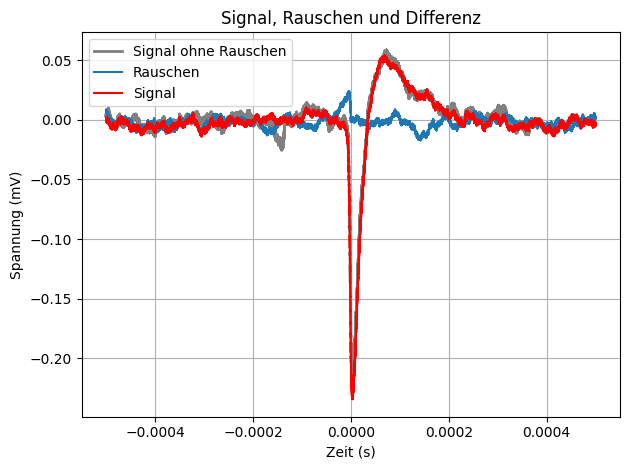

In [2]:
plt.plot(df_signal['time'], y, label='Signal ohne Rauschen', linewidth=2, color='grey' )
plt.plot(df_noise['time'], df_noise['noise'], label='Rauschen')
plt.plot(df_signal['time'], df_signal['signal'], label='Signal', color='red')

plt.xlabel('Zeit (s)')
plt.ylabel('Spannung (mV)')
plt.grid(True)
plt.legend()
plt.title('Signal, Rauschen und Differenz')
plt.tight_layout()
plt.show()


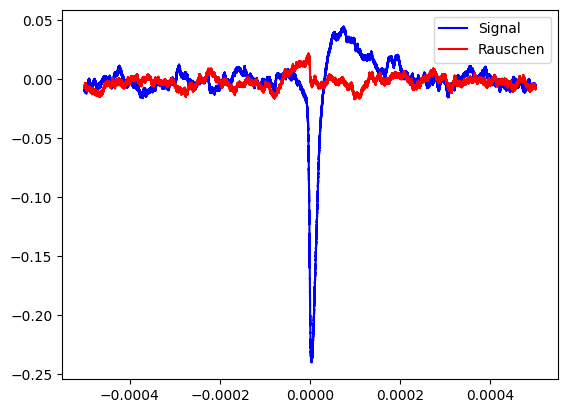

In [2]:
plt.plot(df_signal['time'], df_signal['signal'], label='Signal', color='blue')
plt.plot(df_noise['time'], df_noise['noise'], label='Rauschen', color='red')
plt.legend()
plt.show()


In [7]:
print("⟨Signal⟩:", df_signal['signal'].mean())
print("⟨Rauschen⟩:", df_noise['noise'].mean())
print("⟨Signal ohne Rauschen⟩:", (df_signal['signal'] - df_noise['noise']).mean())


⟨Signal⟩: -0.0020077545860495995
⟨Rauschen⟩: -0.0019112319312499996
⟨Signal ohne Rauschen⟩: -9.652265479959887e-05


In [7]:
import numpy as np
import pandas as pd

df_signal = pd.read_csv('/Users/rojinaksu/PycharmProjects/diy-particle-detector-V2/codes/Signal tests/Tek025.csv', header=None)
df_noise = pd.read_csv('/Users/rojinaksu/PycharmProjects/diy-particle-detector-V2/codes/Signal tests/Tek026.csv', header=None)


df_signal.columns = ['time', 'signal']
df_noise.columns = ['time', 'noise']


voltage_diff = df_signal['signal'] - df_noise['noise']

print("⟨Signal⟩:", df_signal['signal'].mean())
print("⟨Rauschen⟩:", df_noise['noise'].mean())
print("⟨Signal – Rauschen⟩:", voltage_diff.mean())


rms_signal = np.sqrt(np.mean(voltage_diff**2))
rms_noise  = np.sqrt(np.mean(df_noise['noise']**2))

# SNR in dB
snr_db = 20 * np.log10(rms_signal / rms_noise)
print("SNR [dB]:", snr_db)



⟨Signal⟩: -0.0020350738798795994
⟨Rauschen⟩: -0.0022433006250000007
⟨Signal – Rauschen⟩: 0.00020822674512040165
SNR [dB]: 17.32741979257581


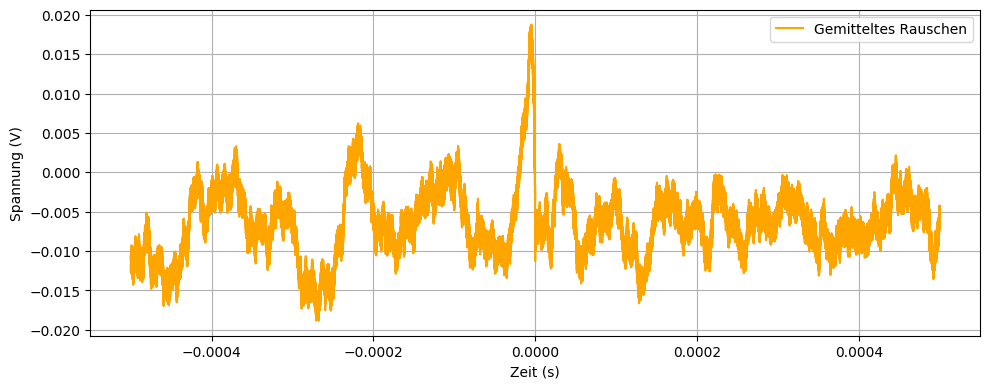

52


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def load_tektronix_csv(path):
    df = pd.read_csv(path, skiprows=10, header=None, names=["time", "voltage"])
    return df.apply(pd.to_numeric, errors='coerce').dropna()

#
# Pfad zur Ordnerstruktur
folder_path = "/Users/rojinaksu/PycharmProjects/diy-particle-detector-V2/codes/Signal tests/messungen_BA"

# Dateien von Tek141.csv bis Tek192.csv
file_names = [f"Tek{str(i).zfill(3)}.csv" for i in range(141, 193)]
file_paths = [os.path.join(folder_path, name) for name in file_names]

# Funktion zum Laden und Bereinigen
def load_clean_csv(path):
    df_raw = pd.read_csv(path, header=None)
    df_clean = df_raw.apply(pd.to_numeric, errors='coerce').dropna()
    df_clean.columns = ["time", "voltage"]
    return df_clean

data = [load_tektronix_csv(path) for path in file_paths if os.path.exists(path)]


# Prüfe, ob Dateien geladen wurden
if not data:
    raise FileNotFoundError("Keine gültigen Dateien gefunden.")

# Gemeinsame Zeitachse
time = data[0]["time"].to_numpy()

# Alle Spannungsverläufe extrahieren und mitteln
noise_array = np.column_stack([df["voltage"].to_numpy() for df in data])
mean_noise = np.mean(noise_array, axis=1)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(time, mean_noise, label="Gemitteltes Rauschen", color="orange")
plt.xlabel("Zeit (s)")
plt.ylabel("Spannung (V)")
#plt.title(f"Gemitteltes Rauschen aus {len(data)} Einzelmessungen")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

print(len(data)) #anzahl der messungen


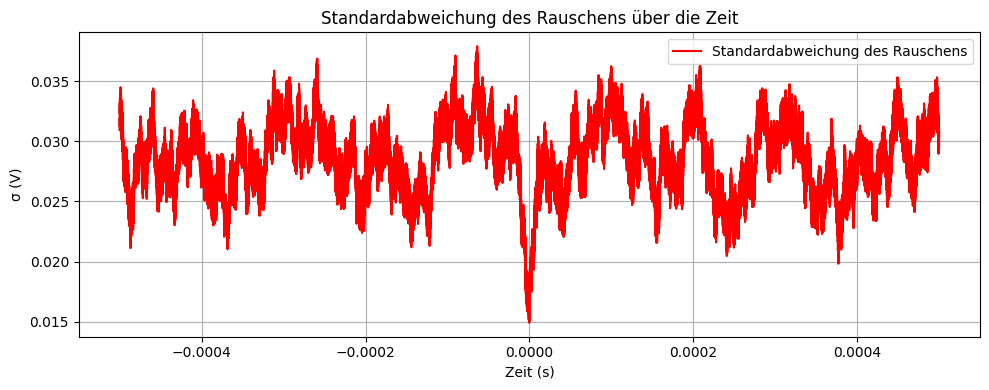

In [12]:
std_noise = np.std(noise_array, axis=1)

plt.figure(figsize=(10, 4))
plt.plot(time, std_noise, label="Standardabweichung des Rauschens", color="red")
plt.xlabel("Zeit (s)")
plt.ylabel("σ (V)")
plt.title("Standardabweichung des Rauschens über die Zeit")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


In [5]:
global_std = np.std(noise_array)
global_mean = np.mean(noise_array)
print(f"Gesamtmittelwert: {global_mean:.5f} V")
print(f"Gesamtstandardabweichung (Rauschpegel): {global_std:.5f} V")


Gesamtmittelwert: -0.00633 V
Gesamtstandardabweichung (Rauschpegel): 0.02903 V


In [6]:
import numpy as np
import pandas as pd

snr =


In [9]:
import pandas as pd
import numpy as np
import os

folder = "/Users/rojinaksu/PycharmProjects/diy-particle-detector-V2/codes/Signal tests/messungen_BA"
filenames = [os.path.join(folder, f"Tek{i}.csv") for i in range(274, 325)]

means = []

for fname in filenames:
    try:
        df = pd.read_csv(fname, skiprows=8)
        voltage = pd.to_numeric(df.iloc[:, 1], errors='coerce')  # Zweite Spalte (Spannung)
        mean = voltage.mean()
        if not np.isnan(mean):
            means.append(mean)
        else:
            print(f"Nur NaNs in {fname}")
    except Exception as e:
        print(f"Fehler bei Datei {fname}: {e}")

print("Einzelne Mittelwerte:", means)
print(f"{len(means)} gültige Dateien gefunden.")
print("Gesamtmittelwert:", np.mean(means))



Einzelne Mittelwerte: [np.float64(-0.0023336031249999996), np.float64(-0.0016207352000000002), np.float64(-0.0019450475124999998), np.float64(-0.0017660167500000014), np.float64(-0.0010154508625), np.float64(-0.0019206204374999994), np.float64(-0.001898251975), np.float64(-0.001968533187499999), np.float64(-0.0021307157), np.float64(-0.0030600993000000007), np.float64(-0.001694245075000001), np.float64(-0.002083050437500001), np.float64(-0.0019707494624999996), np.float64(-0.0026267982374999993), np.float64(-0.0021802374874999994), np.float64(-0.001870281637499999), np.float64(-0.0016667876624999996), np.float64(-0.0020542437249999996), np.float64(-0.002852865162499999), np.float64(-0.002046007324999998), np.float64(-0.002445583212500001), np.float64(-0.002382664087499999), np.float64(-0.0014406281624999991), np.float64(-0.0024821832750000004), np.float64(-0.0015994318249999994), np.float64(-0.0024291627874999996), np.float64(-0.0022336779500000013), np.float64(-0.0018245215500000006),

In [4]:
import pandas as pd

sample_file = "/Users/rojinaksu/PycharmProjects/diy-particle-detector-V2/codes/Signal tests/messungen_BA/Tek274.csv"
df = pd.read_csv(sample_file, nrows=5)
print(df.columns)
print(df.head())


Index(['Model', 'MSO54'], dtype='object')
              Model            MSO54
0     Waveform Type           ANALOG
1  Horizontal Units                s
2   Sample Interval   8.00000000e-10
3     Record Length          1250000
4        Zero Index  631249.00625000


In [8]:
import pandas as pd

file = "/Users/rojinaksu/PycharmProjects/diy-particle-detector-V2/codes/Signal tests/messungen_BA/Tek274.csv"

# Probiere verschiedene Werte für skiprows (z. B. 10 oder 11 oder 16)
df = pd.read_csv(file, skiprows=8)

print(df.head())
print(df.columns)


       TIME       CH2
0 -0.000505 -0.006375
1 -0.000505  0.006641
2 -0.000505 -0.009000
3 -0.000505  0.003125
4 -0.000505 -0.002656
Index(['TIME', 'CH2'], dtype='object')
